In [1]:
%pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn jupyter sdv


  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached notebook-7.5.6-py3-none-any.whl.metadata (10 kB)
Using cached jupyter-1.1.1-py2.py3-none-any.whl (2.7 kB)
Using cached notebook-7.5.6-py3-none-any.whl (14.6 MB)

   ---------------------------------------- 0/2 [notebook]
   ---------------------------------------- 0/2 [notebook]
   ---------------------------------------- 0/2 [notebook]
   ---------------------------------------- 0/2 [notebook]
   ---------------------------------------- 0/2 [notebook]
   ---------------------------------------- 0/2 [notebook]
   ---------------------------------------- 0/2 [notebook]
   ---------------------------------------- 0/2 [notebook]
   ---------------------------------------- 0/2 [notebook]
   ---------------------------------------- 0/2 [notebook]
   ---------------------------------------- 0/2 [notebook]
   ---------------------------------------- 0/2 [notebook]
   ---------------------------------------- 0/

In [6]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score
from xgboost import XGBClassifier
from sdv.single_table import TVAESynthesizer
from sdv.metadata import SingleTableMetadata

# --- 1. ΦΟΡΤΩΣΗ ΚΑΙ ΚΑΘΑΡΙΣΜΟΣ ---
df = pd.read_csv('main.csv')
lab_cols = ['alt', 'ast', 'creatinine', 'platelets', 'glucose']

# Median Imputation & Clipping
for col in lab_cols:
    df[col] = df[col].fillna(df[col].median())
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

df = df.drop_duplicates(subset=['hadm_id'])
df_binary = df[df['liver_group'].isin(['ALCOHOLIC_LIVER_DISEASE', 'MASH_NAFLD'])].copy()

# --- 2. DATA AUGMENTATION (TVAE) ---
print("Δημιουργία συνθετικών ασθενών με MASH...")
df_mash = df_binary[df_binary['liver_group'] == 'MASH_NAFLD'].drop(columns=['liver_group', 'hadm_id', 'subject_id'])
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_mash)
tvae = TVAESynthesizer(metadata, epochs=300)
tvae.fit(df_mash)
synthetic_mash = tvae.sample(num_rows=800) # Ενισχύουμε την κλάση MASH
synthetic_mash['liver_group'] = 'MASH_NAFLD'

# Ένωση πραγματικών με συνθετικά δεδομένα
df_balanced = pd.concat([df_binary, synthetic_mash], axis=0)

# --- 3. ΠΡΟΕΤΟΙΜΑΣΙΑ ΓΙΑ ML ---
features = ['ast', 'alt', 'platelets', 'fib4_score', 'glucose', 'bilirubin', 'age', 'inr']
X = df_balanced[features]
y = LabelEncoder().fit_transform(df_balanced['liver_group'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# --- 4. ΕΚΠΑΙΔΕΥΣΗ ΜΟΝΤΕΛΟΥ (XGBoost) ---
model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# --- 5. ΑΞΙΟΛΟΓΗΣΗ ---
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Δημιουργία συνθετικών ασθενών με MASH...


c:\Users\pkiaz\miniconda3\envs\tf_env\lib\site-packages\sdv\single_table\base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\pkiaz\miniconda3\envs\tf_env\lib\site-packages\sdv\single_table\base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.91      0.91      0.91       257
           1       0.87      0.88      0.88       190

    accuracy                           0.89       447
   macro avg       0.89      0.89      0.89       447
weighted avg       0.89      0.89      0.89       447



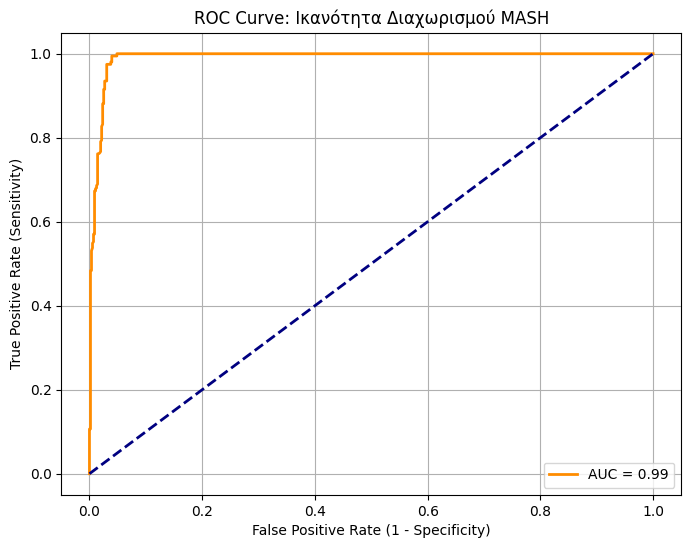

<Figure size 600x500 with 0 Axes>

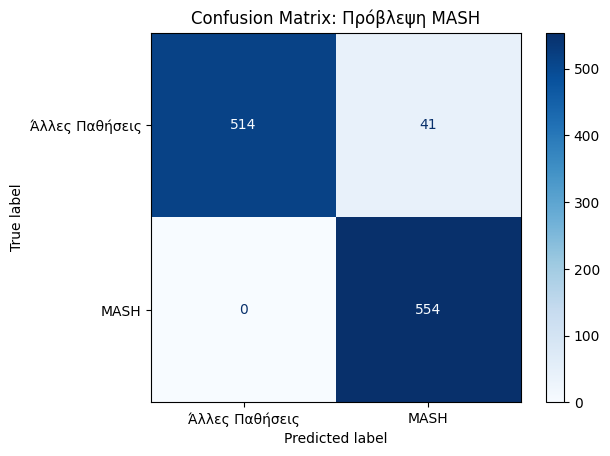

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 1. --- ROC CURVE ---
# Χρειαζόμαστε τις πιθανότητες (probabilities) και όχι τα labels
y_probs = model.predict_proba(X_test)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Διαγώνιος τυχαίας πρόβλεψης
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve: Ικανότητα Διαχωρισμού MASH')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 2. --- CONFUSION MATRIX ---
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
# Χρησιμοποιούμε το ConfusionMatrixDisplay για καθαρό αποτέλεσμα
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Άλλες Παθήσεις', 'MASH'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Πρόβλεψη MASH')
plt.show()